# Data Exploration

## Cameroon Terrain Correction Gravity

This notebook explores the datasets used for the comparison of terrain correction methods.

### Objectives

- Load the original gravity stations.
- Load the kriged terrain grid.
- Verify data integrity.
- Visualize the study area.
- Prepare the datasets for terrain correction calculations.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\MPONO Sabine\cameroon-terrain-correction-gravity-main


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.read_data import (
    read_original_stations,
    read_kriged_grid,
    summarize_stations,
    summarize_grid,
    find_nearest_grid_node,
)

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["figure.dpi"] = 120

In [4]:
from pathlib import Path

print(Path.cwd())

C:\Users\MPONO Sabine\cameroon-terrain-correction-gravity-main\notebooks


In [5]:
STATIONS_FILE = PROJECT_ROOT / "data" / "raw" / "original_stations.xlsx"
GRID_FILE = PROJECT_ROOT / "data" / "raw" / "kriged_grid_surfer.dat"

stations = read_original_stations(STATIONS_FILE)
grid = read_kriged_grid(GRID_FILE)

print("Stations loaded:", len(stations))
print("Grid dimensions:", grid["nx"], "x", grid["ny"])
print("Grid nodes:", grid["nx"] * grid["ny"])

Stations loaded: 1991
Grid dimensions: 598 x 598
Grid nodes: 357604


In [10]:
from src.utils.grid import (
    get_grid_spacing_degrees,
    get_grid_spacing_meters,
    get_grid_extent,
    check_regular_grid,
)

spacing_deg = get_grid_spacing_degrees(grid)
spacing_m = get_grid_spacing_meters(grid)
extent = get_grid_extent(grid)
is_regular = check_regular_grid(grid)

print("Regular grid:", is_regular)

print("\nGrid spacing in degrees:")
for key, value in spacing_deg.items():
    print(f"{key}: {value}")

print("\nApproximate grid spacing in meters:")
for key, value in spacing_m.items():
    print(f"{key}: {value}")

print("\nGrid extent:")
for key, value in extent.items():
    print(f"{key}: {value}")

Regular grid: True

Grid spacing in degrees:
dx_mean_deg: 0.0041730318257956435
dx_min_deg: 0.004173031824999285
dx_max_deg: 0.004173031826200102
dy_mean_deg: 0.005024120603015075
dy_min_deg: 0.005024120602999282
dy_max_deg: 0.005024120603100535

Approximate grid spacing in meters:
dx_m: 462.2540199255807
dy_m: 558.6567219056478
reference_longitude_deg: 9.74765
reference_latitude_deg: 5.0003

Grid extent:
longitude_min_deg: 8.502
longitude_max_deg: 10.9933
latitude_min_deg: 3.5006
latitude_max_deg: 6.5
elevation_min_m: -9.7787087851503
elevation_max_m: 2234.2360969411


In [11]:
print("Station columns:")
print(stations.columns.tolist())

print("\nFirst 5 stations:")
display(stations.head())

print("\nGrid arrays:")
print("x:", grid["x"].shape, grid["x"].min(), grid["x"].max())
print("y:", grid["y"].shape, grid["y"].min(), grid["y"].max())
print("z:", grid["z"].shape)

Station columns:
['longitude', 'latitude', 'altitude_m', 'free_air_anomaly_mgal']

First 5 stations:


,longitude,latitude,altitude_m,free_air_anomaly_mgal
0,9.3017,3.5442,0.0,18.128
1,9.3000,3.5460,0.0,18.028
2,9.2977,3.5488,0.0,18.728
3,9.2930,3.5540,0.0,19.628
4,9.2870,3.5612,0.0,19.328



Grid arrays:
x: (598,) 8.502 10.9933
y: (598,) 3.5006 6.5
z: (598, 598)


In [12]:
lon_min, lon_max = grid["x"].min(), grid["x"].max()
lat_min, lat_max = grid["y"].min(), grid["y"].max()

inside = (
    stations["longitude"].between(lon_min, lon_max)
    & stations["latitude"].between(lat_min, lat_max)
)

print("Total stations:", len(stations))
print("Stations inside grid:", inside.sum())
print("Stations outside grid:", (~inside).sum())

if (~inside).any():
    print("\nStations outside the grid:")
    display(
        stations.loc[
            ~inside,
            ["longitude", "latitude", "altitude_m"]
        ]
    )

Total stations: 1991
Stations inside grid: 1991
Stations outside grid: 0


C:\Users\MPONO Sabine\AppData\Local\Temp\ipykernel_2648\2980458730.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


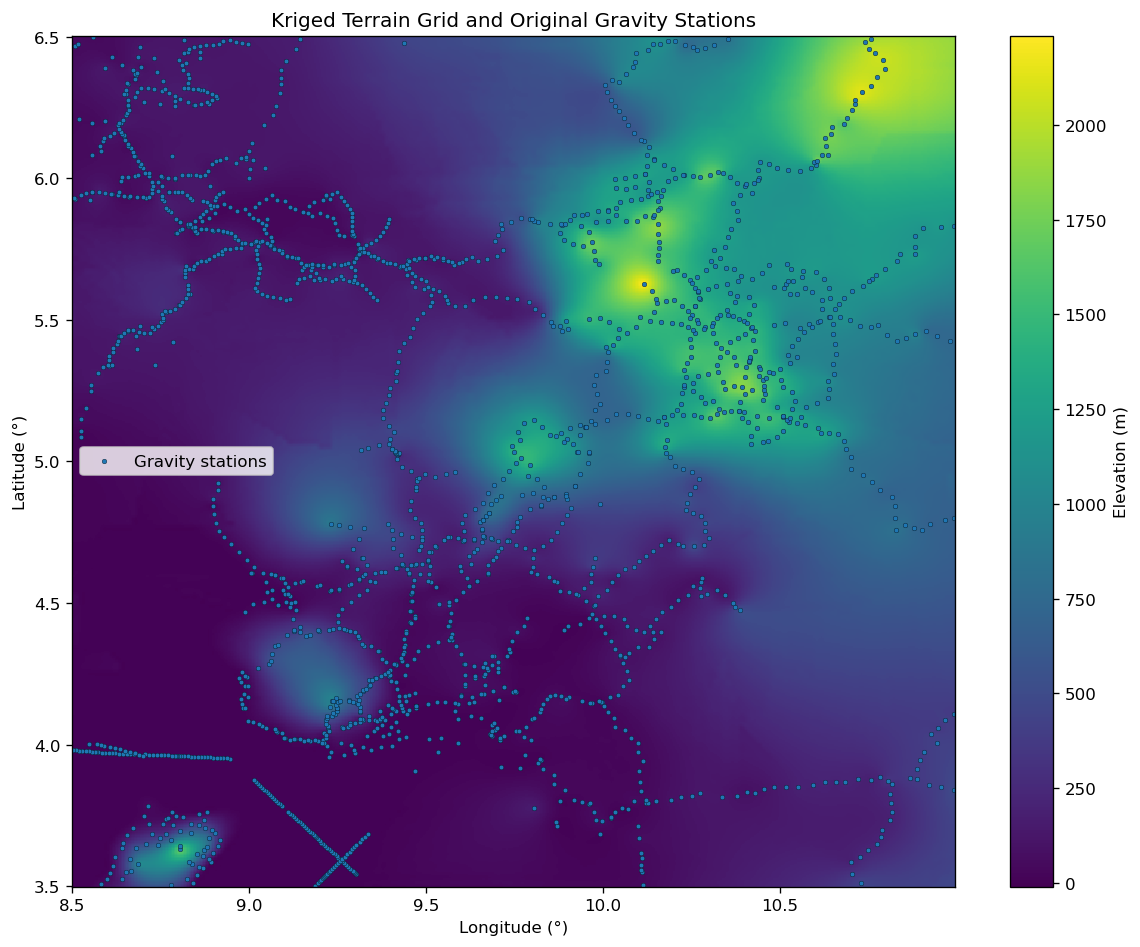

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

terrain = ax.pcolormesh(
    grid["x"],
    grid["y"],
    grid["z"],
    shading="auto"
)

scatter = ax.scatter(
    stations["longitude"],
    stations["latitude"],
    s=8,
    edgecolors="black",
    linewidths=0.2,
    label="Gravity stations"
)

cbar = fig.colorbar(terrain, ax=ax)
cbar.set_label("Elevation (m)")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Kriged Terrain Grid and Original Gravity Stations")
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

# Interpolator of the kriged terrain
terrain_interp = RegularGridInterpolator(
    (grid["y"], grid["x"]),
    grid["z"],
    bounds_error=False,
    fill_value=np.nan
)

# Coordinates: latitude first, longitude second
station_points = np.column_stack([
    stations["latitude"].to_numpy(),
    stations["longitude"].to_numpy()
])

# Terrain elevation interpolated at each gravity station
stations["grid_elevation_m"] = terrain_interp(station_points)

# Difference between station elevation and interpolated terrain
stations["elevation_difference_m"] = (
    stations["altitude_m"] - stations["grid_elevation_m"]
)

print("Number of stations:", len(stations))
print("Stations with altitude = 0 m:",
      (stations["altitude_m"] == 0).sum())

print("\nStation altitude:")
print(stations["altitude_m"].describe())

print("\nInterpolated grid elevation:")
print(stations["grid_elevation_m"].describe())

print("\nStation altitude - grid elevation:")
print(stations["elevation_difference_m"].describe())

Number of stations: 1991
Stations with altitude = 0 m: 147

Station altitude:
count    1991.000000
mean      416.694425
std       519.950120
min         0.000000
25%        55.750000
50%       136.800000
75%       704.150000
max      2258.000000
Name: altitude_m, dtype: float64

Interpolated grid elevation:
count    1991.000000
mean      416.691361
std       519.020674
min        -0.309268
25%        57.094420
50%       136.304219
75%       704.515733
max      2230.059517
Name: grid_elevation_m, dtype: float64

Station altitude - grid elevation:
count    1991.000000
mean        0.003064
std        10.515392
min      -107.211344
25%        -3.229716
50%        -0.056940
75%         2.755513
max       118.962229
Name: elevation_difference_m, dtype: float64


In [16]:
abs_diff = stations["elevation_difference_m"].abs()

print("Elevation consistency diagnostics")
print("---------------------------------")
print("Total stations:", len(stations))
print("|difference| <= 5 m :", (abs_diff <= 5).sum())
print("|difference| <= 10 m:", (abs_diff <= 10).sum())
print("|difference| > 10 m :", (abs_diff > 10).sum())
print("|difference| > 25 m :", (abs_diff > 25).sum())
print("|difference| > 50 m :", (abs_diff > 50).sum())
print("|difference| > 100 m:", (abs_diff > 100).sum())

print("\n10 largest elevation differences:")

largest = stations.loc[
    abs_diff.nlargest(10).index,
    [
        "longitude",
        "latitude",
        "altitude_m",
        "grid_elevation_m",
        "elevation_difference_m"
    ]
].copy()

largest["abs_difference_m"] = (
    largest["elevation_difference_m"].abs()
)

display(
    largest.sort_values(
        "abs_difference_m",
        ascending=False
    )
)

Elevation consistency diagnostics
---------------------------------
Total stations: 1991
|difference| <= 5 m : 1267
|difference| <= 10 m: 1635
|difference| > 10 m : 356
|difference| > 25 m : 60
|difference| > 50 m : 11
|difference| > 100 m: 2

10 largest elevation differences:


,longitude,latitude,altitude_m,grid_elevation_m,elevation_difference_m,abs_difference_m
1552,8.8194,5.6750,369.0,250.037771,118.962229,118.962229
788,9.3126,4.0892,0.0,107.211344,-107.211344,107.211344
357,9.4217,5.0283,410.0,310.885551,99.114449,99.114449
664,8.8042,3.6297,1731.0,1639.071909,91.928091,91.928091
787,9.3200,4.0885,241.4,153.692308,87.707692,87.707692
1547,8.8200,5.6670,165.0,233.487566,-68.487566,68.487566
1726,10.1454,5.8718,1762.6,1701.683583,60.916417,60.916417
546,10.1417,5.8617,1626.0,1686.658703,-60.658703,60.658703
781,9.3135,4.0812,189.3,134.132725,55.167275,55.167275
391,10.3233,5.1667,1729.0,1675.578882,53.421118,53.421118


In [17]:
zero_alt = stations.loc[
    stations["altitude_m"] == 0,
    [
        "longitude",
        "latitude",
        "altitude_m",
        "grid_elevation_m",
        "elevation_difference_m"
    ]
]

print("Stations with altitude = 0 m:", len(zero_alt))

print("\nGrid elevation at these stations:")
print(zero_alt["grid_elevation_m"].describe())

display(zero_alt.head(20))

Stations with altitude = 0 m: 147

Grid elevation at these stations:
count    147.000000
mean       0.830109
std        8.837277
min       -0.309268
25%       -0.001154
50%        0.027166
75%        0.125329
max      107.211344
Name: grid_elevation_m, dtype: float64


,longitude,latitude,altitude_m,grid_elevation_m,elevation_difference_m
0,9.3017,3.5442,0.0,-0.068968,0.068968
1,9.3000,3.5460,0.0,-0.015249,0.015249
2,9.2977,3.5488,0.0,0.040070,-0.040070
3,9.2930,3.5540,0.0,0.083865,-0.083865
4,9.2870,3.5612,0.0,0.005759,-0.005759
5,9.2810,3.5680,0.0,-0.003830,0.003830
6,9.2757,3.5742,0.0,0.002003,-0.002003
7,9.2700,3.5810,0.0,-0.006671,0.006671
8,9.2643,3.5871,0.0,-0.004664,0.004664
9,9.2590,3.5940,0.0,0.001315,-0.001315


In [18]:
import numpy as np

# Mean Earth radius (m)
EARTH_RADIUS_M = 6371008.8

# Reference latitude of the terrain grid
lat0_deg = np.mean(grid["y"])
lat0_rad = np.deg2rad(lat0_deg)

# Approximate metric scale of the regular geographic grid
dx_m = (
    EARTH_RADIUS_M
    * np.cos(lat0_rad)
    * np.deg2rad(np.mean(np.diff(grid["x"])))
)

dy_m = (
    EARTH_RADIUS_M
    * np.deg2rad(np.mean(np.diff(grid["y"])))
)

print("Metric geometry of terrain grid")
print("--------------------------------")
print(f"Reference latitude : {lat0_deg:.6f} deg")
print(f"dx                  : {dx_m:.3f} m")
print(f"dy                  : {dy_m:.3f} m")
print(f"Cell area           : {abs(dx_m * dy_m):.3f} m²")
print(f"Equivalent cell size: {np.sqrt(abs(dx_m * dy_m)):.3f} m")

Metric geometry of terrain grid
--------------------------------
Reference latitude : 5.000300 deg
dx                  : 462.255 m
dy                  : 558.657 m
Cell area           : 258242.029 m²
Equivalent cell size: 508.175 m


In [19]:
# Maximum useful horizontal distance scale of the grid

lon_span_rad = np.deg2rad(grid["x"].max() - grid["x"].min())
lat_span_rad = np.deg2rad(grid["y"].max() - grid["y"].min())

width_m = EARTH_RADIUS_M * np.cos(lat0_rad) * lon_span_rad
height_m = EARTH_RADIUS_M * lat_span_rad

print("\nApproximate physical extent")
print("---------------------------")
print(f"East-West extent : {width_m / 1000:.2f} km")
print(f"North-South extent: {height_m / 1000:.2f} km")
print(f"Grid dimensions   : {grid['nx']} x {grid['ny']}")


Approximate physical extent
---------------------------
East-West extent : 275.97 km
North-South extent: 333.52 km
Grid dimensions   : 598 x 598


In [20]:
from src.utils.geometry import local_distances

# First gravity station
station = stations.iloc[0]

lon_s = station["longitude"]
lat_s = station["latitude"]

# Construct 2-D coordinate matrices
lon_mesh, lat_mesh = np.meshgrid(grid["x"], grid["y"])

dx_grid, dy_grid, r_grid = local_distances(
    lon_mesh,
    lat_mesh,
    lon_s,
    lat_s
)

print("Station used for geometry test")
print("--------------------------------")
print(f"Longitude : {lon_s:.6f} deg")
print(f"Latitude  : {lat_s:.6f} deg")

print("\nDistance arrays")
print("----------------")
print("Shape dx :", dx_grid.shape)
print("Shape dy :", dy_grid.shape)
print("Shape r  :", r_grid.shape)

print("\nDistance diagnostics")
print("--------------------")
print(f"Minimum distance : {r_grid.min():.3f} m")
print(f"Maximum distance : {r_grid.max()/1000:.3f} km")

nearest = np.unravel_index(
    np.argmin(r_grid),
    r_grid.shape
)

print("\nNearest terrain node")
print("--------------------")
print("Array index :", nearest)
print(f"Longitude   : {lon_mesh[nearest]:.6f} deg")
print(f"Latitude    : {lat_mesh[nearest]:.6f} deg")
print(f"Distance    : {r_grid[nearest]:.3f} m")

Station used for geometry test
--------------------------------
Longitude : 9.301700 deg
Latitude  : 3.544200 deg

Distance arrays
----------------
Shape dx : (598, 598)
Shape dy : (598, 598)
Shape r  : (598, 598)

Distance diagnostics
--------------------
Minimum distance : 246.716 m
Maximum distance : 378.510 km

Nearest terrain node
--------------------
Array index : (np.int64(9), np.int64(192))
Longitude   : 9.303222 deg
Latitude    : 3.545817 deg
Distance    : 246.716 m


In [7]:
from src.utils.cells import build_terrain_cells

cells = build_terrain_cells(grid)

print("Terrain cells created")
print("---------------------")
print("nx_cells:", cells["nx_cells"])
print("ny_cells:", cells["ny_cells"])
print("number_of_cells:", cells["number_of_cells"])

Terrain cells created
---------------------
nx_cells: 597
ny_cells: 597
number_of_cells: 356409


In [8]:
from src.utils.neighborhood import build_station_neighborhood

# ------------------------------------------------------------
# Real-data validation of station-terrain neighborhoods
# ------------------------------------------------------------

# Select one station with a non-zero altitude
test_station = stations.loc[stations["altitude_m"] > 0].iloc[0]

station_lon = float(test_station["longitude"])
station_lat = float(test_station["latitude"])
station_z = float(test_station["altitude_m"])

print("Station selected")
print("----------------")
print(f"Longitude : {station_lon:.6f} deg")
print(f"Latitude  : {station_lat:.6f} deg")
print(f"Altitude  : {station_z:.3f} m")

# Radii used to investigate neighborhood growth
radii_km = [1, 2, 5, 10, 20, 50, 100]

print("\nTerrain neighborhoods")
print("---------------------")

for radius_km in radii_km:

    neighborhood = build_station_neighborhood(
        cells=cells,
        station_longitude=station_lon,
        station_latitude=station_lat,
        station_elevation_m=station_z,
        max_radius_m=radius_km * 1000.0,
    )

    n = neighborhood["number_of_cells"]

    if n > 0:
        r = neighborhood["horizontal_distance_m"]
        dh = neighborhood["elevation_difference_m"]

        print(
            f"R = {radius_km:3d} km | "
            f"cells = {n:7d} | "
            f"r_max = {r.max()/1000:8.3f} km | "
            f"dh_min = {dh.min():9.3f} m | "
            f"dh_max = {dh.max():9.3f} m"
        )

    else:
        print(
            f"R = {radius_km:3d} km | "
            "cells = 0"
        )

Station selected
----------------
Longitude : 10.121700 deg
Latitude  : 3.795000 deg
Altitude  : 21.200 m

Terrain neighborhoods
---------------------
R =   1 km | cells =      12 | r_max =    0.974 km | dh_min =     9.053 m | dh_max =    26.977 m
R =   2 km | cells =      48 | r_max =    1.991 km | dh_min =     5.578 m | dh_max =    33.715 m
R =   5 km | cells =     303 | r_max =    4.982 km | dh_min =    -4.057 m | dh_max =    43.208 m
R =  10 km | cells =    1210 | r_max =    9.996 km | dh_min =   -15.071 m | dh_max =    73.926 m
R =  20 km | cells =    4855 | r_max =   19.994 km | dh_min =   -17.397 m | dh_max =   102.262 m
R =  50 km | cells =   26864 | r_max =   49.998 km | dh_min =   -21.708 m | dh_max =   233.892 m
R = 100 km | cells =   85149 | r_max =  100.000 km | dh_min =   -22.632 m | dh_max =   553.020 m
